Example of how to parse the files and load data in dataframes.

In [1]:
#%pip install matplotlib

import os
import matplotlib.pyplot as plt
import matplotlib
import math
matplotlib.use('TkAgg')
%matplotlib notebook
%matplotlib inline


In [2]:
data_path = os.getcwd() + os.sep + 'data'
print(data_path)

C:\Users\Filip\Documents\Examensarbete\data


In [3]:
# Loading data functions
def loader(data_path, blacklist):
    data = []
    all_data_csv = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
    for name in os.listdir(data_path):
        if name != '.DS_Store' and 'csv' not in name and 'txt' not in name:
            print('---------------------------------------------')
            print("Loading walking data for subject: ",name)
            new_path = data_path + os.sep + name
            for name_in in os.listdir(new_path):
                if name_in != '.DS_Store' and name_in not in blacklist:
                    print("Loading test: ", name_in)
                    motion_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'motion.csv')
                    position_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'positions.csv')
                    orientation_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'orientation.csv')
                    steps_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'steps.csv')
                    event_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'events.csv')

                    anon_test = walking_test(
                        name_in, event_csv,
                        motion_csv,
                        orientation_csv,
                        position_csv,
                        steps_csv
                    )
                    data.append(anon_test)

    return data, all_data_csv

class walking_test:
    def __init__(self, filename, events, motion, orientation, positions, steps): #
        self.filename = filename
        self.events = events
        self.motion = motion
        self.orientation = orientation
        self.positions = positions
        self.steps = steps

In [4]:
#%pip install pandas

import pandas as pd

# Uploading metadata and determining blacklist
metadata = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
print("Metadata columns: ", metadata.columns)

noIMU = metadata[metadata['hasMotion'] == False]['testName'].tolist()
noGPS = metadata[metadata['hasGNSS'] == False]['testName'].tolist()
blacklist = noIMU + noGPS
print("Blacklist: ", blacklist)

Metadata columns:  Index(['subject', 'testID', 'testName', 'isPatient', 'distanceReference',
       'hasMotion', 'hasGNSS', 'device', 'distanceByApp', 'totSteps',
       'path curvature', 'total_gaps_time_inertial', 'total_gaps_time_gnss',
       'gt_type', 'country', 'gnss_anonimized', 'duration [s]', 'fs_acc',
       'fs_gnss', 'fs_steps', 'average_walking_speed', 'smartphone_position',
       'smartphone app'],
      dtype='object')
Blacklist:  ['0_0', '0_1', '0_2', '0_3', '0_4', '0_5', '0_6', '0_7', '0_8', '0_9', '0_10', '0_11', '0_12', '0_13', '0_14', '1_0', '1_1', '1_2', '1_3', '1_4', '1_5', '1_6', '1_7', '1_8', '1_9', '2_0', '2_1', '2_2', '2_3', '2_4', '2_5', '2_6', '2_7', '2_8', '2_9', '3_0', '3_5', '3_6', '3_7', '3_8', '3_9', '9_0', '9_1', '9_2', '9_3', '9_4', '9_5', '9_6', '9_7', '9_8', '9_9', '9_10', '15_0', '15_1', '15_2', '15_3', '15_4']


In [5]:
metadata.head()

,subject,testID,testName,isPatient,distanceReference,hasMotion,hasGNSS,device,distanceByApp,totSteps,...,gt_type,country,gnss_anonimized,duration [s],fs_acc,fs_gnss,fs_steps,average_walking_speed,smartphone_position,smartphone app
0,0,0,0_0,True,623,False,True,"Apple iPhone11,8",598.373421,755.0,...,final,UK,True,368,NaN,0.304348,0.380435,1.692935,hand held,Timed Walk
1,0,1,0_1,True,598,False,True,"Apple iPhone11,8",587.334804,699.0,...,final,UK,True,380,NaN,0.292105,0.357895,1.573684,hand held,Timed Walk
2,0,2,0_2,True,584,False,True,"Apple iPhone11,8",577.005522,726.0,...,final,UK,True,359,NaN,0.281337,0.381616,1.626741,hand held,Timed Walk
3,0,3,0_3,True,577,False,True,"Apple iPhone11,8",539.365038,710.0,...,final,UK,True,365,NaN,0.284932,0.372603,1.580822,hand held,Timed Walk
4,0,4,0_4,True,590,False,True,"Apple iPhone11,8",566.744323,715.0,...,final,UK,True,360,NaN,0.277778,0.375000,1.638889,hand held,Timed Walk


In [6]:
# Loading data
selection, info_all_tests = loader(data_path, blacklist=blacklist)
print("Successfully loaded data")

---------------------------------------------
Loading walking data for subject:  subject_0
---------------------------------------------
Loading walking data for subject:  subject_1
---------------------------------------------
Loading walking data for subject:  subject_10
Loading test:  10_0
Loading test:  10_1
Loading test:  10_10
Loading test:  10_11
Loading test:  10_12
Loading test:  10_13
Loading test:  10_14
Loading test:  10_15
Loading test:  10_16
Loading test:  10_17
Loading test:  10_2
Loading test:  10_3
Loading test:  10_4
Loading test:  10_5
Loading test:  10_6
Loading test:  10_7
Loading test:  10_8
Loading test:  10_9
---------------------------------------------
Loading walking data for subject:  subject_11
Loading test:  11_0
Loading test:  11_1
Loading test:  11_10
Loading test:  11_11
Loading test:  11_12
Loading test:  11_13
Loading test:  11_14
Loading test:  11_15
Loading test:  11_2
Loading test:  11_3
Loading test:  11_4
Loading test:  11_5
Loading test:  11_6


## Data

In [7]:
rows, columns = metadata.shape
print(f"The dataset has {rows} rows and {columns} columns.")

The dataset has 203 rows and 23 columns.


In [8]:
# Example of what a walking test contains:
print("Selection[0] contains: ")
print("Filename: ", selection[0].filename)
#Events
print("Events: ", selection[0].events.head())
#Motion
print("Motion: ", selection[0].motion.head())
#Orientation
print("Orientation: ", selection[0].orientation.head())
#Positions
print("Positions: ", selection[0].positions.head())
#Steps
print("Steps: ", selection[0].steps.head())

Selection[0] contains: 
Filename:  10_0
Events:     Unnamed: 0  signalStart  testStart        testEnd
0           0            0     1481.0  361167.000055
Motion:     Unnamed: 0     ms  accelX  accelY  accelZ  accelWithGX  accelWithGY  \
0           0  178.0    -0.1     0.0     0.2         -0.2          3.2   
1           1  192.0    -0.1     0.0     0.3         -0.2          3.2   
2           2  200.0    -0.1    -0.1     0.3         -0.3          3.1   
3           3  218.0    -0.1    -0.2     0.4         -0.2          2.9   
4           4  234.0    -0.1    -0.2     0.4         -0.3          2.9   

   accelWithGZ  rotRateAlpha  rotRateBeta  rotRateGamma  interval  
0          9.4          -2.6          0.8           3.3        16  
1          9.4          -2.6          0.8           3.3        16  
2          9.6          -2.8         -1.4           3.4        16  
3          9.7          -1.6         -2.1           2.4        16  
4          9.8           0.5         -3.4          

## Crowdistans

In [9]:
#Saras code
def crowDist(point1, point2):
    lat1 = point1.latitude
    lat2 = point2.latitude
    lon1 = point1.longitude
    lon2 = point2.longitude
    R = 6371  # km
    dLat = math.radians(lat2 - lat1)
    dLon = math.radians(lon2 - lon1)
    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)
    a = math.sin(dLat / 2) * math.sin(dLat / 2) + \
        math.sin(dLon / 2) * math.sin(dLon / 2) * math.cos(lat1) * math.cos(lat2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = R * c
    return d * 1000

## Calculating distans

In [10]:
import math

for test in selection:
    positions_data = test.positions.copy()  # Important to copy the data to avoid modifying the original

    # Convert time to seconds from start
    positions_data['time_s'] = (positions_data['ms'] - positions_data['ms'].min()) / 1000

    # Calculate distance between points (protects against index errors)
    distances = [0] + [
        crowDist(positions_data.iloc[i-1], positions_data.iloc[i])
        for i in range(1, len(positions_data))
    ]
    positions_data['distance_m'] = distances

    # Total distance
    total_distance = positions_data['distance_m'].sum()
    print(f"Total distance traveled for {test.filename}: {total_distance:.2f} meters")

    # Calculate time difference between measurement points
    positions_data['delta_time_s'] = positions_data['time_s'].diff()

    # Protect against division by small values or zero
    min_time_threshold = 0.1  # Minimum allowed time difference in seconds
    positions_data['delta_time_s'] = positions_data['delta_time_s'].clip(lower=min_time_threshold)

    # Calculate speed in m/s
    positions_data['speed_mps'] = positions_data['distance_m'] / positions_data['delta_time_s']



Total distance traveled for 10_0: 443.74 meters
Total distance traveled for 10_1: 438.21 meters
Total distance traveled for 10_10: 183.98 meters
Total distance traveled for 10_11: 217.64 meters
Total distance traveled for 10_12: 279.55 meters
Total distance traveled for 10_13: 1609.47 meters
Total distance traveled for 10_14: 365.60 meters
Total distance traveled for 10_15: 450.26 meters
Total distance traveled for 10_16: 176.26 meters
Total distance traveled for 10_17: 322.75 meters
Total distance traveled for 10_2: 547.44 meters
Total distance traveled for 10_3: 882.35 meters
Total distance traveled for 10_4: 468.01 meters
Total distance traveled for 10_5: 514.02 meters
Total distance traveled for 10_6: 633.07 meters
Total distance traveled for 10_7: 568.23 meters
Total distance traveled for 10_8: 260.15 meters
Total distance traveled for 10_9: 368.16 meters
Total distance traveled for 11_0: 570.14 meters
Total distance traveled for 11_1: 433.85 meters
Total distance traveled for 11_

In [11]:
rows, columns = metadata.shape
print(f"The dataset has {rows} rows and {columns} columns.")

The dataset has 203 rows and 23 columns.


## Traning a modell

Epoch 1/30


C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1308/1308 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - loss: 0.0435 - val_loss: 0.0376
Epoch 2/30
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - loss: 0.0292 - val_loss: 0.0397
Epoch 3/30
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - loss: 0.0290 - val_loss: 0.0394
Epoch 4/30
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - loss: 0.0288 - val_loss: 0.0411
Epoch 5/30
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - loss: 0.0286 - val_loss: 0.0416
Epoch 6/30
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - loss: 0.0286 - val_loss: 0.0433
Epoch 7/30
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - loss: 0.0286 - val_loss: 0.0439
Epoch 8/30
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - loss: 0.0282 - val_loss: 0.0419
Epoch 9/30
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - loss: 0.0276 - val_loss: 0.0450
Epoch 10/30
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - loss: 0.0269 - val_loss: 0.0476
Epoch 11/30
1308/1308 ━━━━━━━━━━━━━━━━━━━━ 30s 23ms/step - loss: 0.0261 - val_loss: 0.0476
Epoch 12/30
1308/13

C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Test 10_11 har inte tillräckligt med godkänd data (efter filter).
Test 10_13 har inte tillräckligt med godkänd data (efter filter).
Test 10_15 har inte tillräckligt med godkänd data (efter filter).
Test 10_17 har inte tillräckligt med godkänd data (efter filter).


...

Test 17_0 har inte tillräckligt med godkänd data (efter filter).
Test 17_1 har inte tillräckligt med godkänd data (efter filter).
Test 17_2 har inte tillräckligt med godkänd data (efter filter).
Test 17_3 har inte tillräckligt med godkänd data (efter filter).
Test 17_4 har inte tillräckligt med godkänd data (efter filter).


C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScal

Test 8_4 har inte tillräckligt med godkänd data (efter filter).


C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


,Subject,MAE (m),RMSE (m),Actual distance (m),Predicted distance (m),Absolute diff (m),Relative error (%)
0,10_0,58.63,74.02,432.86,288.910004,143.95,33.26
1,10_10,18.47,24.61,157.71,211.330002,53.62,34.00
2,10_12,8.71,10.85,227.34,256.049988,28.71,12.63
3,10_14,57.40,71.94,375.91,256.940002,118.97,31.65
4,10_16,73.21,84.12,157.60,282.630005,125.02,79.33
...,...,...,...,...,...,...,...
117,8_6,21.40,24.50,253.27,297.059998,43.79,17.29
118,8_7,5.17,6.98,417.34,396.290009,21.05,5.04
119,8_8,16.23,22.22,549.81,509.660004,40.15,7.30
120,8_9,49.90,57.31,489.72,409.709991,80.02,16.34


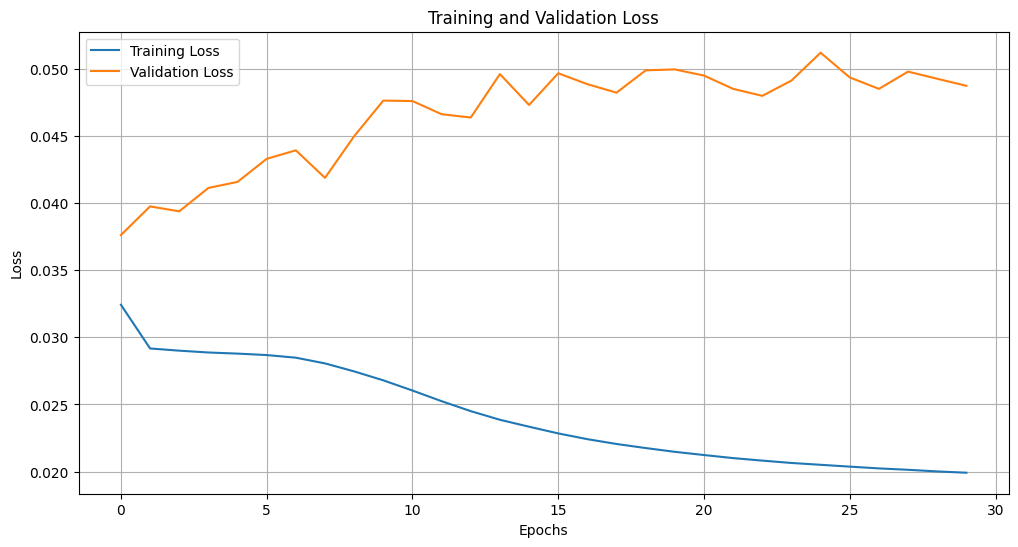

In [49]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import math

# Parametrar
time_step = 100
predict_step = 360
MAX_WALKING_SPEED = 2.5

# Kombinera data från alla tester för träning
all_speeds = []

for test in selection:
    data = test.positions.copy()
    data['time_s'] = (data['ms'] - data['ms'].min()) / 1000

    distances = [0] + [
        crowDist(data.iloc[i - 1], data.iloc[i])
        for i in range(1, len(data))
    ]
    data['distance_m'] = distances
    data['delta_time_s'] = data['time_s'].diff().clip(lower=0.1)
    data['speed_mps'] = data['distance_m'] / data['delta_time_s']

    filtered = data[['speed_mps']].dropna()
    filtered = filtered[filtered['speed_mps'] <= MAX_WALKING_SPEED]
    if not filtered.empty:
        all_speeds.append(filtered)

# Skala och bygg träningsdata
combined_df = pd.concat(all_speeds)
scaler = MinMaxScaler()
scaled_all = scaler.fit_transform(combined_df)

def create_multi_output_dataset(data, time_step, predict_step):
    X, y = [], []
    for i in range(len(data) - time_step - predict_step):
        X.append(data[i:i + time_step, 0])
        y.append(data[i + time_step:i + time_step + predict_step, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_multi_output_dataset(scaled_all, time_step, predict_step)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

# Modell
model = Sequential([
    GRU(64, return_sequences=True, input_shape=(time_step, 1)),
    GRU(64),
    Dense(predict_step)
])
model.compile(optimizer=Adam(0.001), loss='mean_squared_error')
model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2)

# Resultatsamling
results = []

for test in selection:
    data = test.positions.copy()
    data['time_s'] = (data['ms'] - data['ms'].min()) / 1000
    distances = [0] + [
        crowDist(data.iloc[i - 1], data.iloc[i])
        for i in range(1, len(data))
    ]
    data['distance_m'] = distances
    data['delta_time_s'] = data['time_s'].diff().clip(lower=0.1)
    data['speed_mps'] = data['distance_m'] / data['delta_time_s']

    speeds = data[['speed_mps']].dropna()
    speeds = speeds[speeds['speed_mps'] <= MAX_WALKING_SPEED]

    if len(speeds) < time_step:
        print(f"Test {test.filename} har inte tillräckligt med godkänd data (efter filter).")
        continue

    input_seq = speeds['speed_mps'].values[-(time_step):]
    actual_seq = speeds['speed_mps'].values[-(predict_step):]  # Så långt det finns

    scaled_input = scaler.transform(input_seq.reshape(-1, 1))
    input_seq = scaled_input.reshape(1, time_step, 1)

    pred_scaled = model.predict(input_seq, verbose=0)[0]
    pred_scaled = pred_scaled[:len(actual_seq)]
    pred_speeds = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

    pred_distance = np.cumsum(pred_speeds)
    actual_distance = np.cumsum(actual_seq)

    min_len = min(len(pred_distance), len(actual_distance))
    mae = mean_absolute_error(actual_distance[:min_len], pred_distance[:min_len])
    rmse = math.sqrt(mean_squared_error(actual_distance[:min_len], pred_distance[:min_len]))
    final_actual = actual_distance[min_len - 1]
    final_pred = pred_distance[min_len - 1]
    end_diff = abs(final_pred - final_actual)
    rel_error = end_diff / final_actual * 100 if final_actual != 0 else 0.0

    results.append({
        'Subject': test.filename,
        'MAE (m)': round(mae, 2),
        'RMSE (m)': round(rmse, 2),
        'Actual distance (m)': round(final_actual, 2),
        'Predicted distance (m)': round(final_pred, 2),
        'Absolute diff (m)': round(end_diff, 2),
        'Relative error (%)': round(rel_error, 2)
    })

# Skapa DataFrame
results_df = pd.DataFrame(results)

# Lägg till genomsnitt
average_row = {
    'Subject': 'Average',
    'MAE (m)': round(results_df['MAE (m)'].mean(), 2),
    'RMSE (m)': round(results_df['RMSE (m)'].mean(), 2),
    'Actual distance (m)': round(results_df['Actual distance (m)'].mean(), 2),
    'Predicted distance (m)': round(results_df['Predicted distance (m)'].mean(), 2),
    'Absolute diff (m)': round(results_df['Absolute diff (m)'].mean(), 2),
    'Relative error (%)': round(results_df['Relative error (%)'].mean(), 2)
}
results_df_with_avg = pd.concat([results_df, pd.DataFrame([average_row])], ignore_index=True)

# Visa i Jupyter och spara till CSV
display(results_df_with_avg)
results_df_with_avg.to_csv("prediction_results_GRU.csv", index=False)

# Traning and validation loss
history = model.history.history
plt.figure(figsize=(12, 6))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

In [50]:
prediction_result_df = pd.read_csv("prediction_results_GRU.csv")
prediction_result_df.head(122)
#show row 121
prediction_result_df.iloc[121]

Subject                   Average
MAE (m)                     26.88
RMSE (m)                    31.66
Actual distance (m)         397.6
Predicted distance (m)     387.86
Absolute diff (m)            52.7
Relative error (%)          15.41
Name: 121, dtype: object

In [51]:
rows, columns = metadata.shape
print(f"The dataset has {rows} rows and {columns} columns.")

The dataset has 203 rows and 23 columns.


### Boxplot

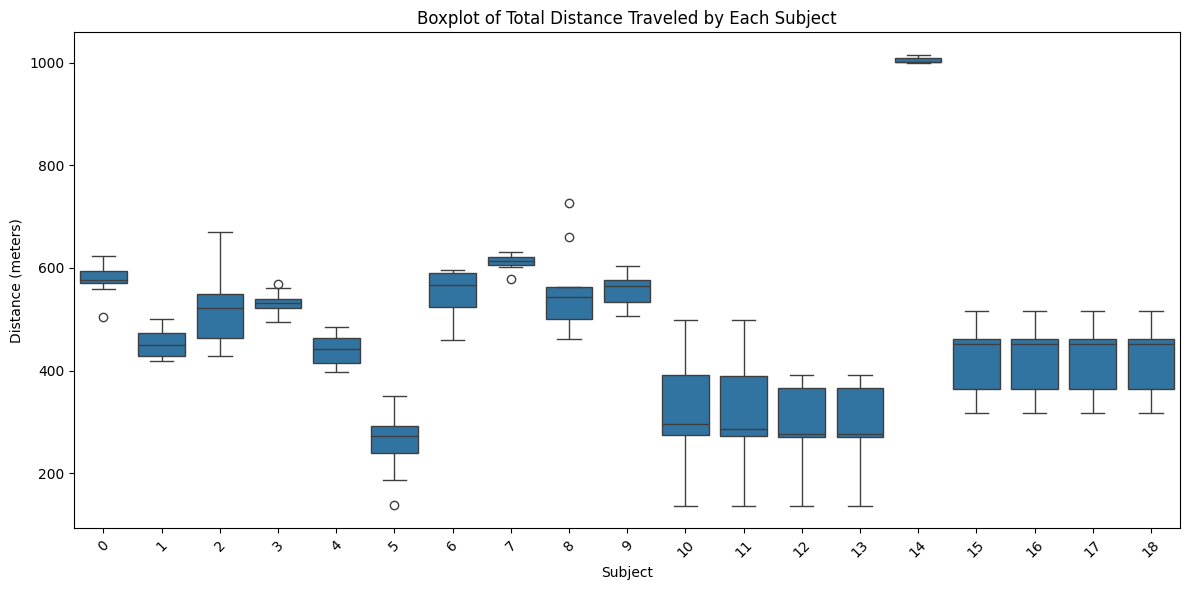

In [12]:
import seaborn as sns

# Extract the subject name
metadata['Subject'] = metadata['testName'].str.split('_').str[0]

# Prepare data for the boxplot
boxplot_data = metadata[['Subject', 'distanceReference']].rename(columns={'distanceReference': 'Distance (m)'})

# Boxplot for total distance traveled by each subject
plt.figure(figsize=(12, 6))
sns.boxplot(x='Subject', y='Distance (m)', data=boxplot_data)
plt.title('Boxplot of Total Distance Traveled by Each Subject')
plt.xlabel('Subject')
plt.ylabel('Distance (meters)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [13]:
metadata[(metadata['subject'] == 14)]

,subject,testID,testName,isPatient,distanceReference,hasMotion,hasGNSS,device,distanceByApp,totSteps,...,country,gnss_anonimized,duration [s],fs_acc,fs_gnss,fs_steps,average_walking_speed,smartphone_position,smartphone app,Subject
168,14,0,14_0,False,1000,True,True,Xiaomi Redmi Note 9 Pro,1035.164078,1366.0,...,SE,False,873,59.980527,1.002291,1.565865,1.145475,hand held,Malisa,14
169,14,1,14_1,False,1005,True,True,Xiaomi Redmi Note 9 Pro,987.643819,1254.0,...,SE,False,761,59.939553,1.005256,1.649146,1.320631,hand held,Malisa,14
170,14,2,14_2,False,1001,True,True,Xiaomi Redmi Note 9 Pro,1002.676164,1272.0,...,SE,False,774,59.979328,1.003876,1.644703,1.293282,hand held,Malisa,14
171,14,3,14_3,False,1011,True,True,Xiaomi Redmi Note 9 Pro,1011.892553,1165.0,...,SE,False,665,59.939850,1.004511,1.753383,1.520301,hand held,Malisa,14
172,14,4,14_4,False,1002,True,True,Xiaomi Redmi Note 9 Pro,1042.694672,1068.0,...,SE,False,582,59.915808,1.001718,1.838488,1.721649,hand held,Malisa,14
173,14,5,14_5,False,1011,True,True,Xiaomi Redmi Note 9 Pro,1021.284249,1097.0,...,SE,False,611,59.949264,1.001637,1.797054,1.654664,hand held,Malisa,14
174,14,6,14_6,False,1001,True,True,Xiaomi Redmi Note 9 Pro,1079.731267,1578.0,...,SE,False,1061,59.947220,1.002828,1.484449,0.943450,hand held,Malisa,14
175,14,7,14_7,False,1001,True,True,Xiaomi Redmi Note 9 Pro,1037.158915,1542.0,...,SE,False,1051,59.941960,1.002854,1.469077,0.952426,hand held,Malisa,14
176,14,8,14_8,False,1001,True,True,Xiaomi Redmi Note 9 Pro,1081.468198,1554.0,...,SE,False,1018,59.975442,1.003929,1.527505,0.983301,hand held,Malisa,14
177,14,9,14_9,False,1015,True,True,Xiaomi Redmi Note 9 Pro,983.830463,1228.0,...,SE,False,752,59.988032,1.006649,1.634309,1.349734,hand held,Malisa,14


#### Loopa alla subject och gör ett dataset att visa:

## Kalman filter

In [14]:
from scipy.interpolate import interp1d
import numpy as np
import geopy
import math
from geopy.distance import geodesic
from filterpy.kalman import KalmanFilter

def crowDist(point1, point2):
    lat1 = point1.latitude
    lat2 = point2.latitude
    lon1 = point1.longitude
    lon2 = point2.longitude
    R = 6371
    dLat = math.radians(lat2 - lat1)
    dLon = math.radians(lon2 - lon1)
    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)
    a = math.sin(dLat / 2) ** 2 + math.sin(dLon / 2) ** 2 * math.cos(lat1) * math.cos(lat2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = R * c
    return d * 1000

def calculate_crowfly_distances(position):
    coords = list(zip(position['latitude'], position['longitude']))
    distances = []

    for i in range(len(coords) - 1):
        point1 = type('Point', (object,), {'latitude': coords[i][0], 'longitude': coords[i][1]})
        point2 = type('Point', (object,), {'latitude': coords[i+1][0], 'longitude': coords[i+1][1]})
        dist = crowDist(point1, point2)
        distances.append(dist)

    return np.array(distances)

def interpolate_confidence(confInterval, gps_time_stamps, motion_time_stamps):
    interp_func = interp1d(gps_time_stamps, confInterval, kind='linear', fill_value="extrapolate")
    return interp_func(motion_time_stamps)

def interpolate_gps_data(gps_time_stamps, distance_traveled, confInterval, time_stamps):
    gps_cumsum = np.cumsum(distance_traveled)
    gps_time_stamps = gps_time_stamps[1:]
    confInterval = confInterval[1:]

    interp_fn = interp1d(gps_time_stamps, gps_cumsum, kind='linear', fill_value='extrapolate')
    interp_cumulativesum = interp_fn(time_stamps)
    interpolated_distances = np.diff(interp_cumulativesum, prepend=interp_cumulativesum[0])

    interpolated_confidence = interpolate_confidence(confInterval, gps_time_stamps, time_stamps)

    return interpolated_distances, interpolated_confidence, interp_cumulativesum

def setup_KalmanFiltering(dt, accel_magnitude, confInterval, time_stamps, distance_traveled):
    kf = KalmanFilter(dim_x=3, dim_z=3)

    kf.F = np.array([[1, dt, 0.5 * dt**2],
                     [0, 1, dt],
                     [0, 0, 1]])

    kf.P = np.eye(3) * 100

    kf.H = np.eye(3)

    mean_confidence = np.mean(confInterval)
    R_factor = np.clip(mean_confidence, 1, 60)

    kf.R = np.array([[0.1 * R_factor, 0, 0],
                     [0, 10 * R_factor, 0],
                     [0, 0, R_factor]])

    kf.B = np.array([[0], [0], [1]])

    accel_Q = np.std(accel_magnitude)
    dt2 = dt ** 2
    dt3 = dt2 * dt / 2
    dt4 = dt2 ** 2 / 4

    kf.Q = np.array([[dt4 * accel_Q, dt3 * accel_Q, dt2 * accel_Q / 2],
                     [dt3 * accel_Q, dt2 * accel_Q, dt * accel_Q],
                     [dt2 * accel_Q / 2, dt * accel_Q, accel_Q]])

    initial_position = 0
    initial_velocity = (distance_traveled[1] - distance_traveled[0]) / ((time_stamps[1] - time_stamps[0]) / 1000)
    initial_acceleration = accel_magnitude[0]

    kf.x = np.array([initial_position, initial_velocity, initial_acceleration])

    return kf

def update_Kalman_with_position(kf, accel_magnitude, distance_traveled, time_stamps, gps_time_stamps, confInterval):
    total_distance = 0.0
    previous_position = kf.x[0]
    total_loops = 0

    interpolated_distances, interpolated_confidence, observed_positions = interpolate_gps_data(
        gps_time_stamps, distance_traveled, confInterval, time_stamps
    )

    print("Original Total Distance:", np.sum(distance_traveled))
    print("Interpolated Total Distance:", np.sum(interpolated_distances))

    for i in range(1, min(len(accel_magnitude), len(interpolated_distances), len(interpolated_confidence))):
        dt = (time_stamps[i] - time_stamps[i - 1]) / 1000

        accel = accel_magnitude[i]
        distance_step = interpolated_distances[i]

        kf.F = np.array([[1, dt, 0.5 * dt ** 2],
                         [0, 1, dt],
                         [0, 0, 1]])

        sigma_acc = np.std(accel_magnitude) * 2
        dt2 = dt ** 2
        dt3 = dt2 * dt / 2
        dt4 = dt2 ** 2 / 4

        kf.Q = np.array([
            [dt4 * sigma_acc, dt3 * sigma_acc, dt2 * sigma_acc / 2],
            [dt3 * sigma_acc, dt2 * sigma_acc, dt * sigma_acc],
            [dt2 * sigma_acc / 2, dt * sigma_acc, sigma_acc]
        ])

        R_factor = np.clip(interpolated_confidence[i], 0.01, 50)
        kf.R = np.eye(3) * R_factor

        kf.predict()

        estimated_velocity = distance_step / dt
        z = np.array([observed_positions[i], estimated_velocity, accel])

        kf.update(z)

        total_distance += abs(kf.x[0] - previous_position)
        previous_position = kf.x[0]
        total_loops += 1

    return kf, total_distance, total_loops


In [19]:
def calculate_XYZ(motion_df):
    return np.sqrt(motion_df['accelX']**2 + motion_df['accelY']**2 + motion_df['accelZ']**2).values

kalman_results = []

for test in selection:
    print("Selected test filename: ", test.filename)
    time_stamps = test.motion['ms'].values
    dt = 1.0
    accel_magnitude = calculate_XYZ(test.motion)
    downsampled_time_stamps = time_stamps[::4]
    gps_time_stamps = test.positions['ms'].values
    distance_traveled = calculate_crowfly_distances(test.positions)
    confInterval = test.positions['confInterval']

    kf = setup_KalmanFiltering(dt, accel_magnitude, confInterval, downsampled_time_stamps, distance_traveled)
    kf, total_distance, total_loops = update_Kalman_with_position(
        kf, accel_magnitude, distance_traveled, downsampled_time_stamps, gps_time_stamps, confInterval
    )

    kalman_results.append({
        'filename': test.filename,
        'total_distance': total_distance,
        'total_loops': total_loops,
        'raw_gps_distance': np.sum(distance_traveled)
    })

# Convert results to DataFrame for easier viewing
kalman_results_df = pd.DataFrame(kalman_results)
display(kalman_results_df)

Selected test filename:  10_0
Original Total Distance: 443.7421089591658
Interpolated Total Distance: 445.3758154100882
Selected test filename:  10_1
Original Total Distance: 438.21491705727476
Interpolated Total Distance: 349.4433953426803
Selected test filename:  10_10
Original Total Distance: 183.98304110068855
Interpolated Total Distance: 184.41651245134025
Selected test filename:  10_11
Original Total Distance: 217.6350875298196
Interpolated Total Distance: 174.32011568714248
Selected test filename:  10_12
Original Total Distance: 279.54607071108865
Interpolated Total Distance: 279.0303465069047
Selected test filename:  10_13
Original Total Distance: 1609.4727356650326
Interpolated Total Distance: 113.2097746410277
Selected test filename:  10_14
Original Total Distance: 365.6039771078573
Interpolated Total Distance: 319.00610266185095
Selected test filename:  10_15
Original Total Distance: 450.2598892151336
Interpolated Total Distance: 306.9850150154135
Selected test filename:  10

C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\scipy\interpolate\_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


Selected test filename:  18_0
Original Total Distance: 382.33384525368865
Interpolated Total Distance: 320.90874796813785
Selected test filename:  18_1
Original Total Distance: 428.57693154844395
Interpolated Total Distance: 372.6497722158041
Selected test filename:  18_2
Original Total Distance: 488.3424037653962
Interpolated Total Distance: 481.9132964561273
Selected test filename:  18_3
Original Total Distance: 519.6754696788915
Interpolated Total Distance: 486.3026366363457
Selected test filename:  18_4
Original Total Distance: 529.2079528687613
Interpolated Total Distance: 522.061390912681
Selected test filename:  3_1
Original Total Distance: 653.0456535051109
Interpolated Total Distance: 559.4241940249992
Selected test filename:  3_2
Original Total Distance: 1050.910538608529
Interpolated Total Distance: 1037.9448317884353
Selected test filename:  3_3
Original Total Distance: 787.7430346701918
Interpolated Total Distance: 554.4748428586804
Selected test filename:  3_4
Original To

,filename,total_distance,total_loops,raw_gps_distance
0,10_0,447.424578,5377,443.742109
1,10_1,441.860335,5416,438.214917
2,10_10,186.523579,3596,183.983041
3,10_11,225.485599,3615,217.635088
4,10_12,287.535303,3602,279.546071
...,...,...,...,...
142,8_5,592.371621,5397,578.256236
143,8_6,559.506173,1938,554.819790
144,8_7,440.909856,4755,437.147832
145,8_8,564.696291,5388,547.865751


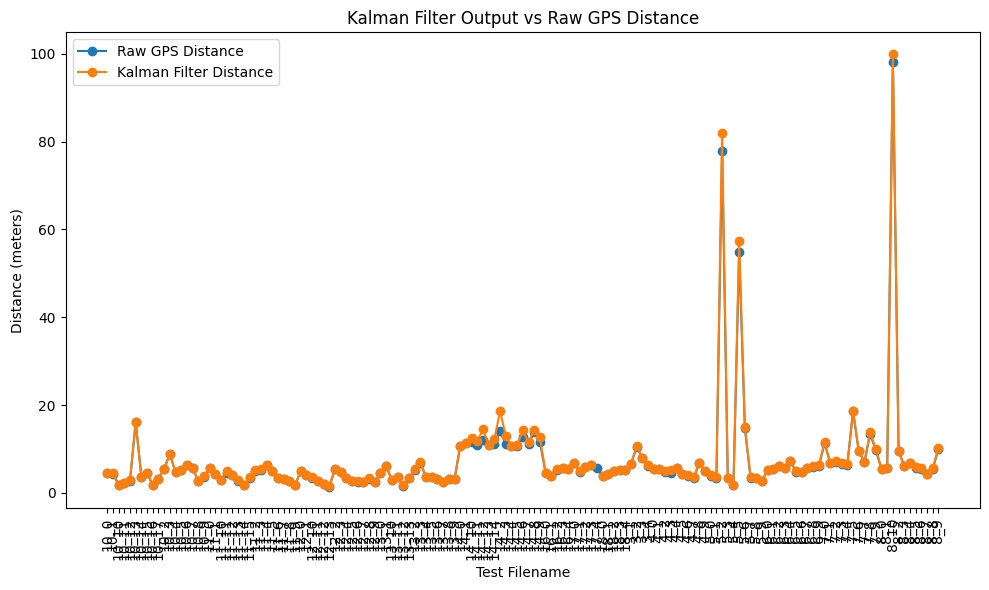

In [ ]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))
plt.plot(kalman_results_df['filename'], kalman_results_df['raw_gps_distance'] / 10, 'o-', label='Raw GPS Distance')
plt.plot(kalman_results_df['filename'], kalman_results_df['total_distance'] / 10, 'o-', label='Kalman Filter Distance')
plt.xlabel('Test Filename')
plt.ylabel('Distance (meters)')
plt.title('Kalman Filter Output vs Raw GPS Distance')
plt.legend()
plt.xticks(rotation=90)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}'))
plt.tight_layout()
plt.show()

   total_distance  raw_gps_distance
0      447.424578        443.742109
1      441.860335        438.214917
2      186.523579        183.983041
3      225.485599        217.635088
4      287.535303        279.546071
5     1618.937196       1609.472736
6      366.697567        365.603977
7      459.911641        450.259889
8      185.592341        176.264005
9      327.544287        322.747203


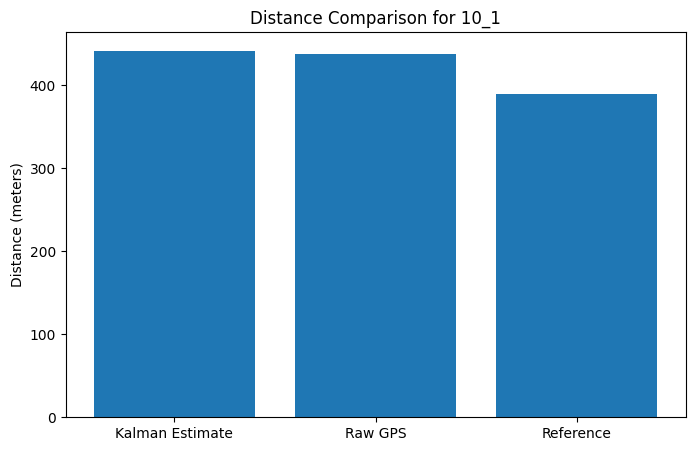

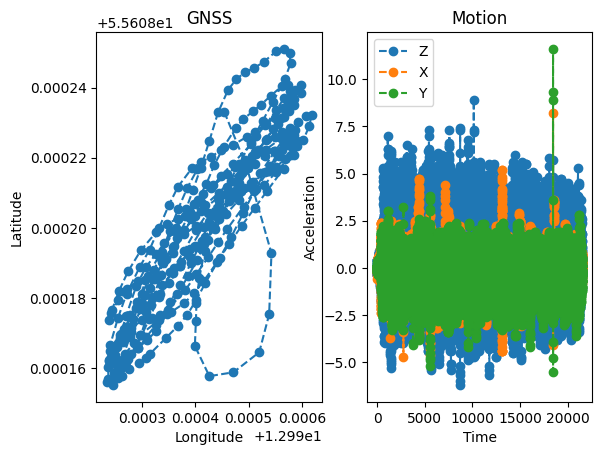

In [16]:
# Example of how to plot position data
fig = plt.figure()
ax = fig.add_subplot(121)
ax.plot(selection[0].positions['longitude'], selection[0].positions['latitude'],'o--')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('GNSS')

ax = fig.add_subplot(122)
ax.plot(selection[0].motion['accelZ'],'o--', label='Z')
ax.plot(selection[0].motion['accelX'],'o--', label='X')
ax.plot(selection[0].motion['accelY'],'o--', label='Y')
ax.set_xlabel('Time')
ax.set_ylabel('Acceleration')
ax.legend()
ax.set_title('Motion')
plt.show()
